# I. Installation des librairies

Installation des librairies à partir du fichier `requirements.txt`

# II. Importation des libairies

In [5]:
# Manipulation des données
import numpy as np
import pandas as pd

# Visualitation
import seaborn as sns
import matplotlib.pyplot as plt

# Modèles de régression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Vérification des résultats de sklearn
import statsmodels.api as sm
import cvxopt
from statsmodels.regression.linear_model import OLS

# Répertoire de travail et gestion d'erreur
import os

In [6]:
# Importation du package frenezik : Simulation et régressions régularisées
from frenezik import Residuals, TargetPredictors, Regularization

# III. Définition du repertoire de travail

In [7]:
# Définition du repertoire de travail
chemin = r"C:\..."
mkdir_data = "data"
mkdir_graphics = "graphics"

# Création des dossiers
try :
    # Définir le repertoire de travail
    os.chdir(chemin)

    # Création du dossier pour les graphiques
    os.mkdir(mkdir_data)

    # Création du dossier pour les bases de données
    os.mkdir(mkdir_graphics)

except FileExistsError:
    print("L'un des dossiers existe déjà")

L'un des dossiers existe déjà


# IV. Simulation des données

## IV.1 Simulation Residus

In [8]:
# Taille de la population
PopulationSize = 500

# Noyau de reproductibilité
RandomSeed = 1980

# Instanciation de la classe <<Residuals>>
Resid = Residuals(population_size=PopulationSize, random_seed=RandomSeed)

# Paramètre de la moyenne
LawMean = 2.81

# Paramètre de la variance
LawVar = 3.89

# Fonction pour simuler les residus
Residus = Resid.Simulation(law="normal", law_parameters=[LawMean, LawVar])
Residus

array([-0.06792843,  6.30685971,  3.12613713,  4.2300371 ,  0.18905088,
        3.93032917,  1.23665046, -0.33483093,  0.1587267 ,  3.04283049,
       -0.86581127, -5.50105284,  5.7476575 ,  9.29244685,  9.70000089,
       -2.96363719,  7.72949449,  5.78634785,  7.70657654, -0.53830384,
        6.05291669,  7.42567823, -4.27099556,  1.71168665,  2.25695003,
       -0.36880389, -0.03880965,  2.76208604,  1.00244483,  6.17404004,
        2.09784985,  4.96028266, 10.53457162,  5.49343063,  8.8558437 ,
        1.47217082, -1.43190755, 11.26943427, -1.43312044, -2.12035973,
        2.6733515 ,  0.45909924, 11.22168541,  6.12993254,  0.97796165,
       -2.50978747, -0.14289129,  0.24672966, 13.8305744 ,  4.12914288,
        7.75310739, -0.02562863,  4.38947636,  1.82278973,  1.72827432,
       -0.2289149 ,  0.34718377,  6.08634972,  3.65904802,  0.84161049,
        6.20225818,  9.60732214,  4.11428389,  2.60387894, -4.2671608 ,
        2.32980489, -0.31363513,  7.64707786, -0.73710926,  1.15

In [9]:
# Statistiques descriptives des residus simulées
Resid.Statistics(residuals_simulated=Residus, decimals=3)

,Name,Value
0,Count,500.000
1,Mean,2.893
2,Variance,15.014
3,Q25,0.279
4,Q50,2.750
5,Q75,5.630
6,Min,-7.522
7,Max,13.831
8,Skewness,0.018
9,Kurtosis,-0.253


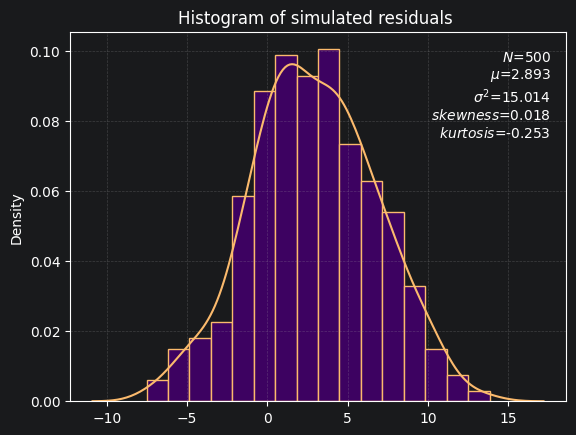

In [10]:
 # Histogramme des residus simulés
Resid.Visualization(residuals_simulated=Residus, figure='histogram')
plt.savefig(f'{mkdir_graphics}/histogram_simulated_residuals.png')

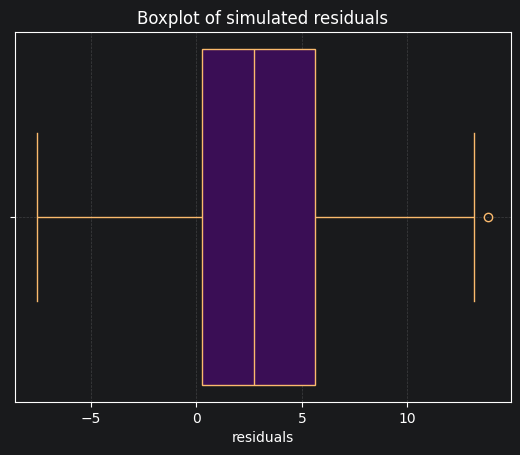

In [11]:
# Boxplot des residus simulés
Resid.Visualization(residuals_simulated=Residus, figure="boxplot")
plt.savefig(f'{mkdir_graphics}/boxplot_simulated_residuals.png')

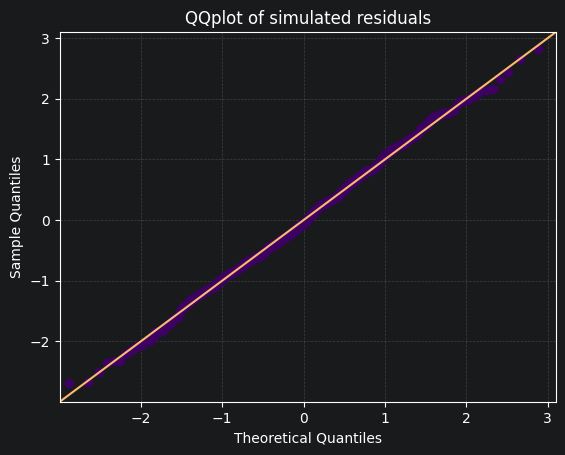

<Figure size 640x480 with 0 Axes>

In [12]:
# QQplot des residus simulés
Resid.Visualization(residuals_simulated=Residus, figure="qqplot")
plt.savefig(f'{mkdir_graphics}/qqplot_simulated_residuals.png')

## IV.2 Simulation des données de la population

In [13]:
# Coefficients réels
TrueCoefficients = np.arange(-20, 20, 4.5)

# Fonction pour simuler les variables d'entrée X et la variable cible y
TarPred = TargetPredictors(population_size=PopulationSize, true_coefficients=TrueCoefficients)
data_population = TarPred.Simulation(residuals_simulated=Residus)
data_population.head(5)

,y,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9
0,-10.855954,0.311729,0.164438,0.602659,1.400893,0.512749,0.158183,1.138557,0.211461,0.247421
1,22.801989,1.198986,-0.443863,1.394170,0.811113,1.086322,0.268830,1.176703,1.728208,1.724521
2,9.994869,1.864570,0.318354,-0.352532,0.911213,0.866974,0.291439,-0.553097,2.097230,1.993658
3,28.779673,1.264282,-0.488332,-0.963007,0.260557,1.398117,0.275257,0.626494,0.978262,1.239956
4,-15.320280,0.817006,0.471960,0.542231,1.694668,-0.142386,0.231937,1.630578,0.774944,0.245971


In [14]:
# Sauvegarder les données de la population
data_population.to_csv(f'{mkdir_data}/data_population.csv', index = False)

<Figure size 800x600 with 0 Axes>

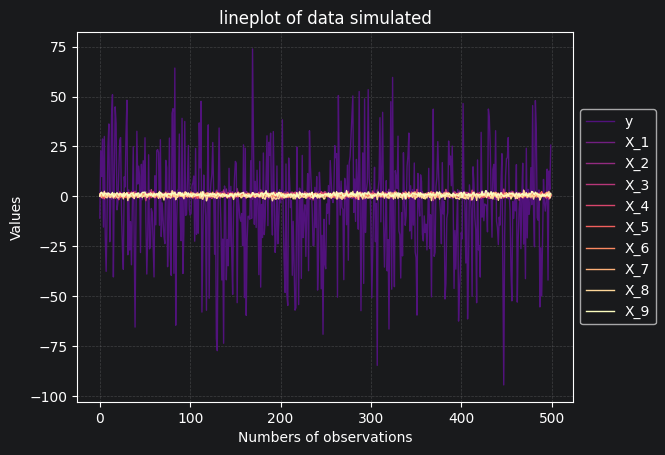

<Figure size 640x480 with 0 Axes>

In [15]:
# Lineplot des données issues de la population
plt.figure(figsize=(8,6))
TarPred.Visualization_X_y(data_simulated=data_population, figure='lineplot')
plt.savefig(f'{mkdir_graphics}/lineplot_data_population.png')

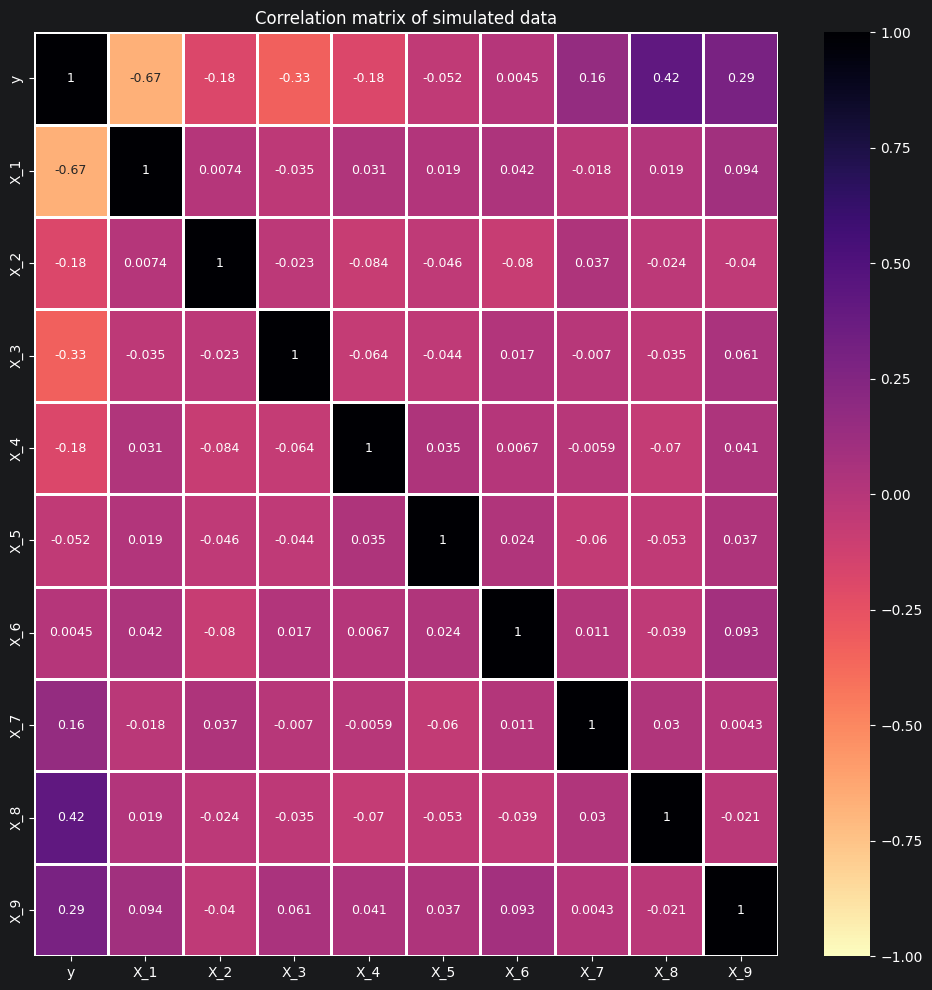

<Figure size 640x480 with 0 Axes>

In [16]:
# Matrice de correlation des données issues de la population
plt.figure(figsize=(12,12))
TarPred.Visualization_X_y(data_simulated=data_population, figure='correlation_matrix')
plt.savefig(f'{mkdir_graphics}/correlation_matrix_data_population.png')

## IV.4 Simulation des données de l'échantillon

In [17]:
# Taille de l'échantillon souhaitée
SampleSize = 100

# Fonction pour constituer un échantillon à partir des données de la population
data_sample = TarPred.Sampling(population_simulated=data_population, sample_size=SampleSize, random_seed=RandomSeed)
data_sample.head(5)

,y,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9
333,-40.826162,1.479969,-0.131922,1.235226,1.320234,1.412961,0.238304,0.196320,-0.467561,0.971251
481,-25.200555,1.883180,0.086875,0.858422,1.474373,0.903516,0.222615,0.962106,0.150419,1.003366
409,5.802862,0.071475,-0.125101,0.598145,0.670685,0.938628,0.245703,1.244334,0.713803,0.211780
287,52.516784,0.659056,0.147578,-1.532805,1.380111,0.724255,0.254046,1.679743,1.286024,1.684087
489,-49.738408,1.429825,0.408409,1.315031,1.117324,2.419316,0.259389,0.003607,0.821147,-0.106631


In [18]:
# Sauvegarder les données de l'échantillon
data_sample.to_csv(f'{mkdir_data}/data_sample.csv', index = False)

# V. Sélection et séparation des bases de données

In [19]:
# Choix de la base de donnée de l'étude
data_names = ['data_population', 'data_sample']

# Base de dnnées de l'étude
data_final = pd.read_csv(f"{mkdir_data}/{data_names[0]}.csv")

# Aperçu de la base de données
data_final.head(5)

,y,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9
0,-10.855954,0.311729,0.164438,0.602659,1.400893,0.512749,0.158183,1.138557,0.211461,0.247421
1,22.801989,1.198986,-0.443863,1.394170,0.811113,1.086322,0.268830,1.176703,1.728208,1.724521
2,9.994869,1.864570,0.318354,-0.352532,0.911213,0.866974,0.291439,-0.553097,2.097230,1.993658
3,28.779673,1.264282,-0.488332,-0.963007,0.260557,1.398117,0.275257,0.626494,0.978262,1.239956
4,-15.320280,0.817006,0.471960,0.542231,1.694668,-0.142386,0.231937,1.630578,0.774944,0.245971


In [20]:
# Base d'apprentissage et d'évaluation à l'aide de la validation croissée
data_train, data_test = train_test_split(data_final, test_size=0.2, random_state=RandomSeed)

# Variable à prédire
Target = np.array(data_final['y']).reshape(-1,1)

# Variables prédictives
Predictors = data_final.drop('y', axis=1)

In [21]:
# Sauvegarder les données d'entrainement et les données de validation
data_train.to_csv(f'{mkdir_data}/data_train.csv', index = False)
data_test.to_csv(f'{mkdir_data}/data_test.csv', index = False)

# VI. Régression MCO ~ Statsmodels

In [22]:
# Estimation du modèle de Régression par MCO avec constante
RegressionsModels = OLS(Target, sm.add_constant(Predictors))
regMC0_sm = RegressionsModels.fit()

# Résultats du modèle de régression par MCO
regMC0_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     2581.
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        10:16:01   Log-Likelihood:                -1384.6
No. Observations:                 500   AIC:                             2789.
Df Residuals:                     490   BIC:                             2831.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9865      1.132      2.639      0.009       0.763       5.210
X_1          -20.1274      0.183   -109.797      0.000     -20.488     -19.767
X_2          -15.8945      0.564    -28.202      0.000     -17.002     -14.787
X_3          -11.1245      0.191    -58.337      0.000     -11.499     -10.750
X_4           -6.6683      0.236    -28.242      0.000      -7.132      -6.204
X_5           -2.0595      0.314     -6.559      0.000      -2.676      -1.443
X_6            4.3128      4.178      1.032      0.302      -3.896      12.521
X_7            6.7097      0.324     20.718      0.000       6.073       7.346
X_8           11.3113      0.184     61.466      0.000      10.950      11.673
X_9           16.1919      0.273     59.362      0.000      15.656      16.728
==============================================================================
Omnibus:                        1.332   Durbin-Watson:                   1.906
Prob(Omnibus):                  0.514   Jarque-Bera (JB):                1.283
Skew:                           0.009   Prob(JB):                        0.526
Kurtosis:                       2.752   Cond. No.                         57.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# VII. Régression Régularisée RIDGE

## VII.1 Valeur unique de $\alpha$

In [23]:
# Valeur du facteur de pénalité (alpha)
AlphaValue = 5

# Intercept du modèle
InterceptState = True

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors,
                       target=Target,
                       alpha=AlphaValue,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
ResultsRidge = Regul.Penalized_Regression(model='ridge')
ResultsRidge

,Variables,Estimators,Std.error,T.stats,P.vals
0,Intercept,3.687946,0.666433,5.533863,3.132540e-08
1,X_1,-19.882186,0.183291,108.473248,2.000000e-16
2,X_2,-14.428777,0.514889,28.023090,2.000000e-16
3,X_3,-10.948459,0.190595,57.443600,2.000000e-16
4,X_4,-6.493645,0.234412,27.701857,2.000000e-16
5,X_5,-1.961721,0.307564,6.378250,1.791229e-10
6,X_6,0.801080,0.626668,1.278317,2.011378e-01
7,X_7,6.483920,0.316649,20.476657,2.000000e-16
8,X_8,11.205511,0.183951,60.915747,2.000000e-16
9,X_9,15.800527,0.268421,58.864717,2.000000e-16


## VII.2 Etude du chemin de régularisation ( $\alpha_k$ )

In [24]:
# Intervalle du facteur de pénalité (alpha)
AlphaList = np.linspace(0, 9, 19)

# Intercept du modèle
InterceptState = True

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors,
                       target=Target,
                       alpha=AlphaList,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
SummaryCoefRidge = Regul.Penalized_Regression(model='ridge')
SummaryCoefRidge

,Variables,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0
0,Intercept,2.986508,3.327093,3.478042,3.559691,3.608510,3.639315,3.659257,3.672206,3.680437,3.685373,3.687946,3.688792,3.688357,3.686965,3.684853,3.682199,3.679139,3.675778,3.672196
1,X_1,-20.127354,-20.100784,-20.075539,-20.050813,-20.026359,-20.002079,-19.977925,-19.953872,-19.929903,-19.906010,-19.882186,-19.858427,-19.834731,-19.811094,-19.787516,-19.763994,-19.740529,-19.717120,-19.693765
2,X_2,-15.894526,-15.746206,-15.592720,-15.439360,-15.287664,-15.138201,-14.991204,-14.846759,-14.704887,-14.565571,-14.428777,-14.294459,-14.162567,-14.033047,-13.905844,-13.780902,-13.658167,-13.537583,-13.419098
3,X_3,-11.124505,-11.105993,-11.087931,-11.070091,-11.052401,-11.034833,-11.017372,-11.000009,-10.982738,-10.965556,-10.948459,-10.931446,-10.914514,-10.897662,-10.880888,-10.864190,-10.847568,-10.831020,-10.814545
4,X_4,-6.668341,-6.650524,-6.632575,-6.614694,-6.596940,-6.579333,-6.561881,-6.544587,-6.527451,-6.510471,-6.493645,-6.476972,-6.460448,-6.444071,-6.427838,-6.411746,-6.395792,-6.379975,-6.364290
5,X_5,-2.059513,-2.047706,-2.037040,-2.026878,-2.017026,-2.007402,-1.997965,-1.988691,-1.979566,-1.970579,-1.961721,-1.952988,-1.944373,-1.935873,-1.927483,-1.919201,-1.911022,-1.902945,-1.894967
6,X_6,4.312843,2.814031,2.115648,1.711153,1.446972,1.260668,1.122070,1.014814,0.929255,0.859340,0.801080,0.751735,0.709365,0.672555,0.640249,0.611645,0.586120,0.563184,0.542448
7,X_7,6.709717,6.687631,6.664759,6.641736,6.618749,6.595874,6.573145,6.550578,6.528183,6.505963,6.483920,6.462054,6.440365,6.418850,6.397509,6.376340,6.355340,6.334508,6.313841
8,X_8,11.311264,11.298763,11.287644,11.277019,11.266620,11.256338,11.246122,11.235944,11.225789,11.215647,11.205511,11.195379,11.185247,11.175114,11.164980,11.154843,11.144703,11.134560,11.124415
9,X_9,16.191939,16.158403,16.120610,16.081357,16.041491,16.001358,15.961123,15.920879,15.880678,15.840553,15.800527,15.760614,15.720826,15.681170,15.641652,15.602275,15.563044,15.523961,15.485027


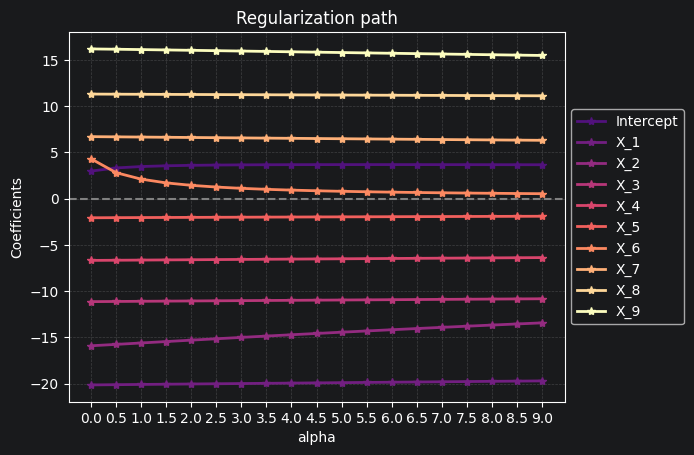

In [25]:
# Visualisation de l'effet de rétrécissement selon une approche par courbe
Regul.Visualization_Shrinking(penalized_coefficients_table=SummaryCoefRidge,
                              variables_selected=None, # non utilisé lorsque figure = "curve"
                              alpha_value_selected=None, # non utilisé lorsque figure = "curve"
                              figure='curve')

## VII.3 Analyse des résidus de régression

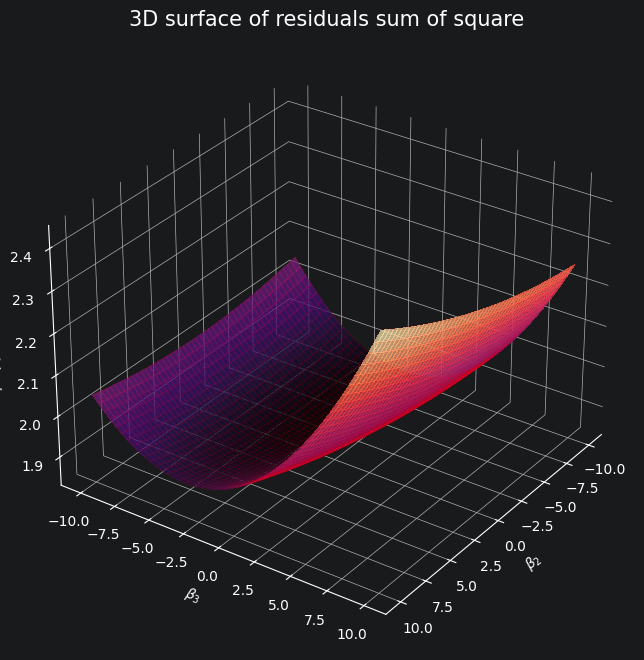

In [26]:
# Surface pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-10, 10, 50)
Beta2 = np.linspace(-10, 10, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors,
                        target=Target,
                        penalized_coefficients_table=SummaryCoefRidge,
                        var_1='X_2',
                        var_2='X_3',
                        intercept=0,
                        figure='surface3D')
plt.savefig(f'{mkdir_graphics}/surface_3D_X2_vs_X3_ridge.png')

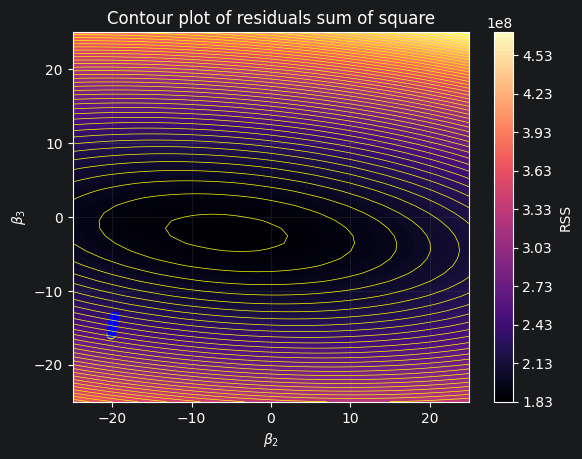

<Figure size 640x480 with 0 Axes>

In [27]:
# Carte de niveau pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-25, 25, 50)
Beta2 = np.linspace(-25, 25, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors,
                        target=Target,
                        penalized_coefficients_table=SummaryCoefRidge,
                        var_1='X_2',
                        var_2='X_3',
                        intercept=0,
                        figure='contour_map')
plt.savefig(f'{mkdir_graphics}/contour_plot_X2_vs_X3_ridge.png')

# VIII. Régression Régularisée LASSO

## VIII.1 Valeur unique de $\alpha$

In [28]:
# Valeur du facteur de pénalité (alpha)
AlphaValue = 5.0

# Intercept du modèle
InterceptState = True

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors,
                       target=Target,
                       alpha=AlphaValue,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
ResultsLasso = Regul.Penalized_Regression(model='lasso')
ResultsLasso

,Variables,Estimators
0,Intercept,5.567701
1,X_1,-13.757267
2,X_2,-0.000000
3,X_3,-4.087008
4,X_4,-0.000000
5,X_5,-0.000000
6,X_6,0.000000
7,X_7,0.000000
8,X_8,6.391085
9,X_9,2.571057


## VIII.2 Etude du chemin de régularisation ( $\alpha_k$ )

In [29]:
# Intervalle du facteur de pénalité (alpha)
AlphaList = np.linspace(0, 9, 19)

# Intercept du modèle
InterceptState = True

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors,
                       target=Target,
                       alpha=AlphaList,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
SummaryCoefLasso = Regul.Penalized_Regression(model='lasso')
SummaryCoefLasso

,Variables,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0
0,Intercept,2.986508,3.238059,3.165016,3.375386,4.525986,4.280010,4.034030,4.089788,4.582430,5.075075,5.567701,6.060366,6.415798,5.676453,4.937108,4.197763,3.458418,2.822013,2.445323
1,X_1,-20.127354,-19.530047,-18.929863,-18.325211,-17.696503,-17.050815,-16.405122,-15.751609,-15.086839,-14.422072,-13.757267,-13.092538,-12.437703,-11.862125,-11.286547,-10.710968,-10.135390,-9.565361,-9.009330
2,X_2,-15.894526,-10.447173,-5.052422,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
3,X_3,-11.124505,-10.328993,-9.571891,-8.829148,-8.132539,-7.429264,-6.725986,-6.043556,-5.391366,-4.739177,-4.087008,-3.434800,-2.789375,-2.197924,-1.606472,-1.015020,-0.423568,-0.000000,-0.000000
4,X_4,-6.668341,-5.574524,-4.457582,-3.345287,-2.417027,-1.484332,-0.551636,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
5,X_5,-2.059513,-0.396514,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
6,X_6,4.312843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,X_7,6.709717,5.049380,3.309161,1.552284,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,X_8,11.311264,10.932771,10.523271,10.098253,9.616596,9.108941,8.601285,8.072104,7.511765,6.951427,6.391085,5.830751,5.272583,4.731741,4.190898,3.650056,3.109213,2.562821,2.002426
9,X_9,16.191939,14.865942,13.553960,12.248333,10.852676,9.447511,8.042345,6.655079,5.293739,3.932400,2.571057,1.209721,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


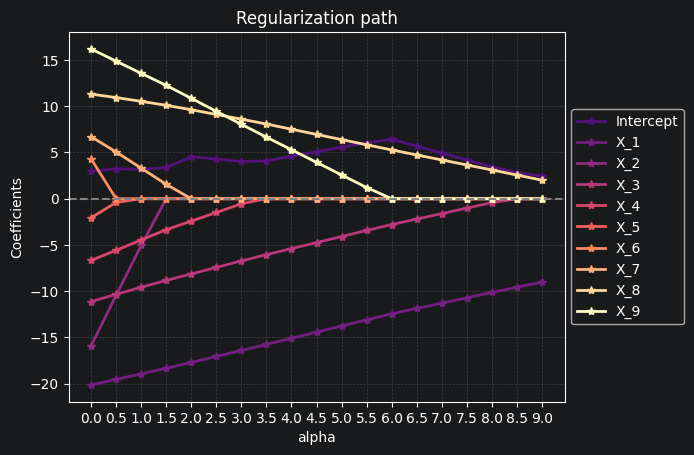

In [30]:
# Visualisation de l'effet de rétrécissement selon une approche par courbe
Regul.Visualization_Shrinking(penalized_coefficients_table=SummaryCoefLasso,
                              variables_selected=None, # non utilisé lorsque figure = "curve"
                              alpha_value_selected=None, # non utilisé lorsque figure = "curve"
                              figure='curve')

## VIII.2 Analyse des résidus de régression

In [31]:
ResidualsPredictedLasso = Regul.Predict(penalized_coefficients_table=SummaryCoefLasso,
                       alpha=2.0,
                       target=Target,
                       predictors=Predictors,
                       purpose = 'residuals_predicted')
ResidualsPredictedLasso[:5]

array([ 39.65223009, 304.75899621,  16.03236705, 274.25826684,
        49.05751196])

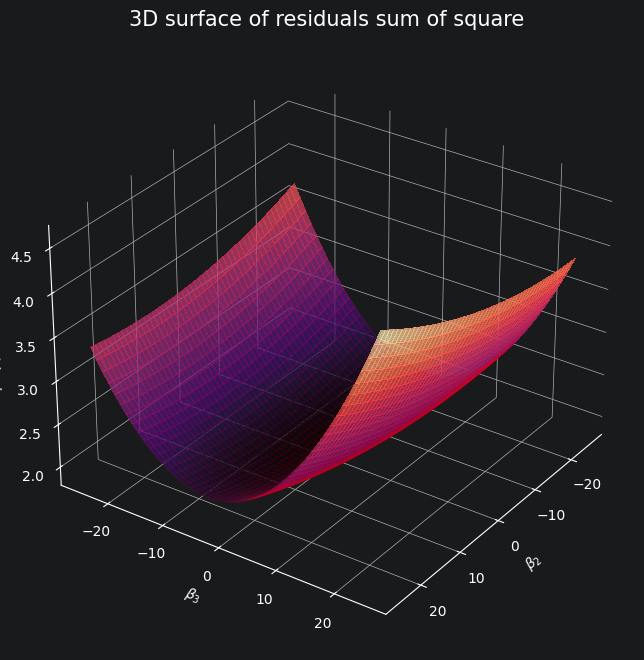

In [32]:
# Surface pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-25, 25, 50)
Beta2 = np.linspace(-25, 25, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors,
                        target=Target,
                        penalized_coefficients_table=SummaryCoefLasso,
                        var_1='X_2',
                        var_2='X_3',
                        intercept=0,
                        figure='surface3D')
plt.savefig(f'{mkdir_graphics}/surface_3D_X2_vs_X3_Lasso.png')

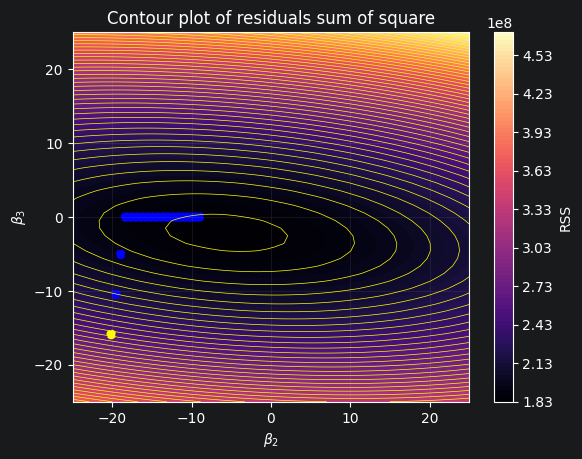

<Figure size 640x480 with 0 Axes>

In [33]:
# Carte de niveau pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-25, 25, 50)
Beta2 = np.linspace(-25, 25, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors,
                        target=Target,
                        penalized_coefficients_table=SummaryCoefLasso,
                        var_1='X_2',
                        var_2='X_3',
                        intercept=0,
                        figure='contour_map')
plt.savefig(f'{mkdir_graphics}/contour_plot_X2_vs_X3_lasso.png')

In [34]:
# Synthèse des coefficients de régression
list_estimators_names =  SummaryCoefRidge['Variables']
list_estimators_mco_values = SummaryCoefRidge['0.0']
list_estimators_ridge_values = SummaryCoefRidge['5.0']
list_estimators_lasso_values = SummaryCoefLasso['5.0']
df_barplot = pd.DataFrame({
    'variables' : list_estimators_names,
    'true_coefficients': np.insert(TrueCoefficients, 0, 0),
    'mco': list_estimators_mco_values,
    'ridge': list_estimators_ridge_values,
    'lasso':list_estimators_lasso_values
})
df_barplot

,variables,true_coefficients,mco,ridge,lasso
0,Intercept,0.0,2.986508,3.687946,5.567701
1,X_1,-20.0,-20.127354,-19.882186,-13.757267
2,X_2,-15.5,-15.894526,-14.428777,-0.000000
3,X_3,-11.0,-11.124505,-10.948459,-4.087008
4,X_4,-6.5,-6.668341,-6.493645,-0.000000
5,X_5,-2.0,-2.059513,-1.961721,-0.000000
6,X_6,2.5,4.312843,0.801080,0.000000
7,X_7,7.0,6.709717,6.483920,0.000000
8,X_8,11.5,11.311264,11.205511,6.391085
9,X_9,16.0,16.191939,15.800527,2.571057


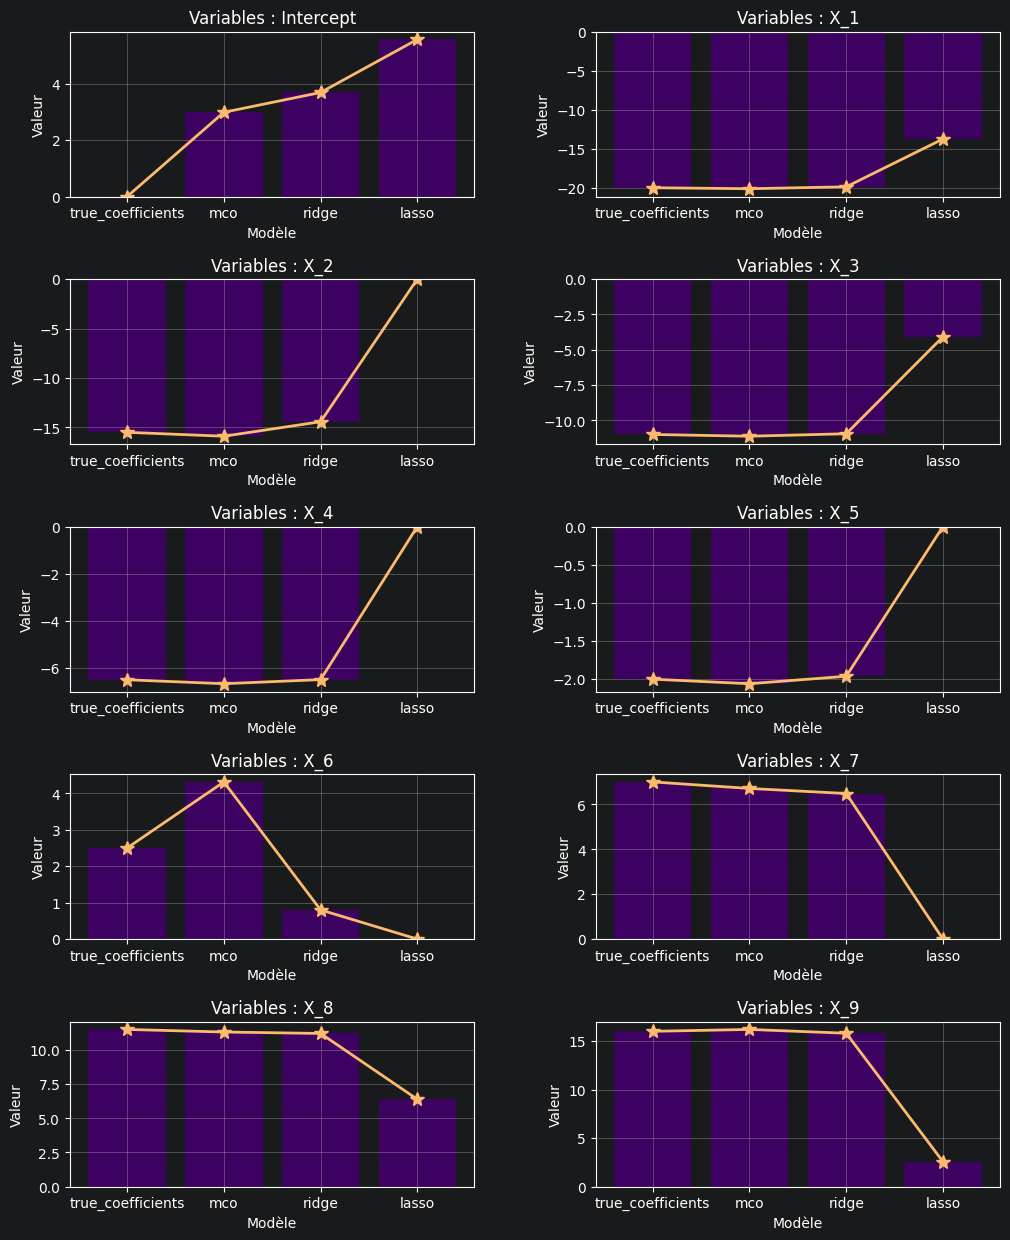

In [35]:
# Visualisation de l'effet de retrecissement
import matplotlib.pyplot as plt

fig, ax = plt.subplots(5, 2, figsize=(12, 15))
axs = ax.flatten()

for i, estimators in enumerate(df_barplot['variables']):
    estimators_names = df_barplot.columns[1:]
    estimators_values = df_barplot.loc[df_barplot['variables'].isin([estimators]), estimators_names].values[0]

    axs[i].bar(estimators_names, estimators_values, color='#3d0261', align='center', capsize=10)
    axs[i].plot(estimators_names, estimators_values, color='#fbba6d', marker='*', linewidth=2, ms=10)

    axs[i].set_xlabel('Modèle')
    axs[i].set_ylabel("Valeur")
    axs[i].set_title(f"Variables : {estimators}")
    axs[i].grid(True)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()